In [6]:
# 📦 1. 모델 및 테스트셋 로딩
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import pandas as pd

model_log = joblib.load("../outputs/model_log.pkl")
model_rf = joblib.load("../outputs/model_rf.pkl")
model_lgb = joblib.load("../outputs/model_lgb.pkl")
model_smote = joblib.load("../outputs/model_smote.pkl")
X_test, y_test = joblib.load("../outputs/Xy_test.pkl")


In [7]:
# 📊 2. ROC Curve 함수 정의
def plot_roc_curves(models, X_test, y_test):
    plt.figure(figsize=(10, 6))
    
    for name, model in models.items():
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
    
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend(loc="lower right")
    plt.grid()
    plt.tight_layout()
    plt.show()


In [8]:
# 📈 3. Precision-Recall Curve 함수 정의
def plot_pr_curves(models, X_test, y_test):
    plt.figure(figsize=(10, 6))
    
    for name, model in models.items():
        y_proba = model.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        plt.plot(recall, precision, label=name)
    
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve Comparison")
    plt.legend(loc="upper right")
    plt.grid()
    plt.tight_layout()
    plt.show()


In [9]:
# 📊 4. 성능 막대그래프 함수 정의 (선택적 df_results 사용)
def plot_metric_bars(results_df):
    results_df.set_index("method")[["recall", "precision", "f1"]].plot(
        kind="bar", figsize=(10, 6), ylim=(0, 1), colormap="Set2"
    )
    plt.title("Model Performance Comparison")
    plt.ylabel("Score")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


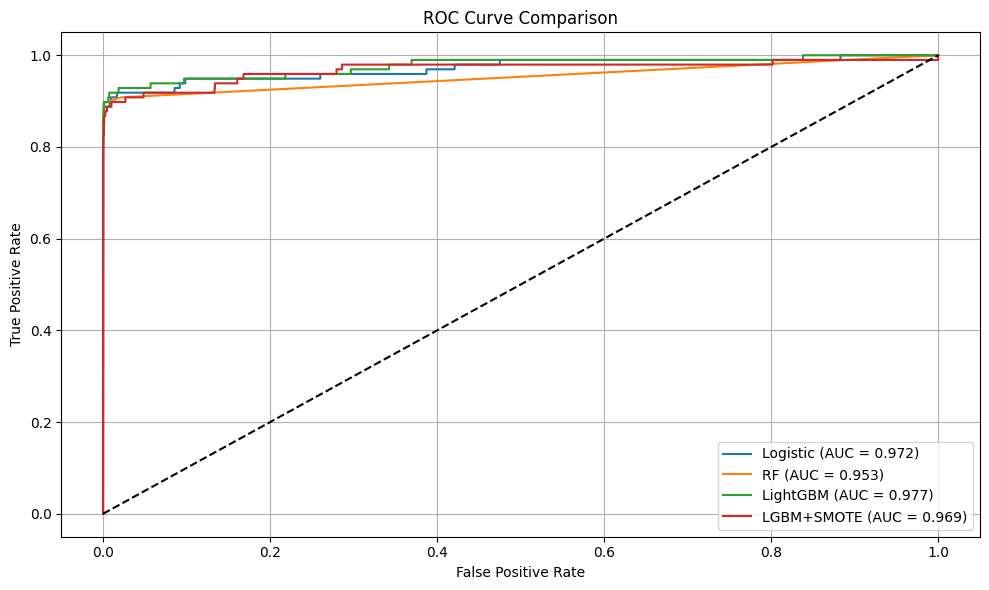

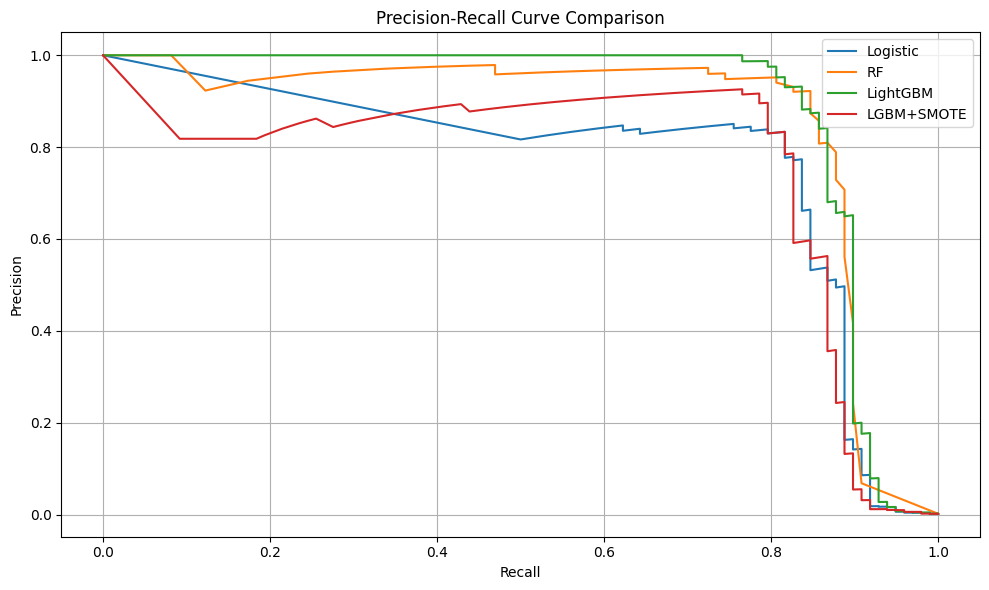

In [10]:
# 🚀 5. 함수 실행

model_dict = {
    "Logistic": model_log,
    "RF": model_rf,
    "LightGBM": model_lgb,
    "LGBM+SMOTE": model_smote
}

plot_roc_curves(model_dict, X_test, y_test)
plot_pr_curves(model_dict, X_test, y_test)


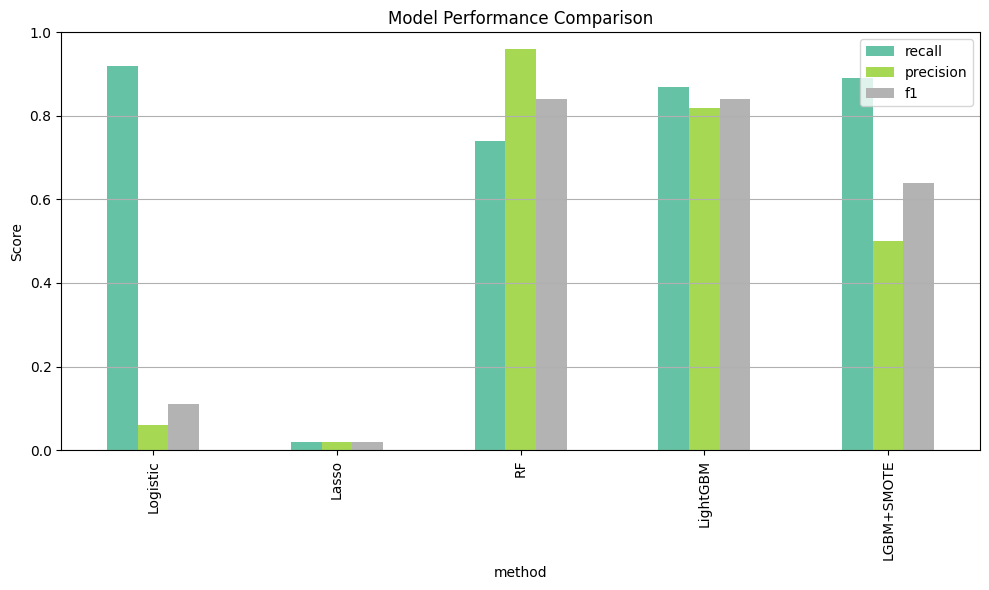

In [12]:

df_results = pd.DataFrame([
    {"method": "Logistic", "recall": 0.92, "precision": 0.06, "f1": 0.11},
    {"method": "Lasso", "recall": 0.02, "precision": 0.02, "f1": 0.02},
    {"method": "RF", "recall": 0.74, "precision": 0.96, "f1": 0.84},
    {"method": "LightGBM", "recall": 0.87, "precision": 0.82, "f1": 0.84},
    {"method": "LGBM+SMOTE", "recall": 0.89, "precision": 0.50, "f1": 0.64}
])

plot_metric_bars(df_results)
